#  Objetivo del Notebook

Aplicar un modelo de **Regresión Logística** para predecir la probabilidad de que una persona **haya sobrevivido o no** al hundimiento del Titanic, utilizando como base un conjunto de datos reales.

Se busca:
- Comprender cómo preparar datos reales.
- Entrenar un modelo de clasificación binaria.
- Evaluar su desempeño con métricas estándar.

---

## ¿Qué hace el código?

### 1. Importación de librerías
Se cargan las librerías necesarias para análisis de datos (`pandas`, `numpy`), visualización (`seaborn`, `matplotlib`), y machine learning (`sklearn`).

### 2. Carga de datos
Se utiliza el dataset **Titanic** desde un repositorio en línea. Este dataset contiene información de pasajeros como:
- Edad
- Sexo
- Clase del ticket
- Precio pagado
- Puerto de embarque
- Si sobrevivió o no (objetivo)

### 3. Preprocesamiento
- Se eliminan columnas irrelevantes como `Name`, `Ticket`, `Cabin`.
- Se imputan valores faltantes en `Age` y `Embarked`.
- Se codifican variables categóricas como `Sex` y `Embarked` en variables numéricas (one-hot encoding).

### 4. División en variables predictoras (X) y objetivo (y)
- `X`: todas las columnas menos `Survived`.
- `y`: la columna `Survived`, que será la variable objetivo (1 = sobrevivió, 0 = no sobrevivió).

### 5. Separación en conjuntos de entrenamiento y prueba
- 80% para entrenamiento
- 20% para prueba
- Con `random_state=42` para reproducibilidad

### 6. Entrenamiento del modelo
Se crea y entrena un modelo de **regresión logística**, ideal para problemas de clasificación binaria como este.

### 7. Evaluación del modelo
Se calculan:
- **Accuracy (precisión global)**: proporción total de predicciones correctas.
- **Matriz de confusión**: muestra cuántos verdaderos positivos, falsos positivos, etc.
- **Reporte de clasificación**: entrega precisión, recall, F1-score para cada clase.

### 8. Visualización
Se crea un **heatmap** para visualizar la matriz de confusión de manera clara e intuitiva.

---



# Ejemplo de Regresión Logística con el Dataset Titanic

In [ ]:
# Paso 1: Importar librerías
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [ ]:
# Paso 2: Cargar los datos
url = "https://raw.githubusercontent.com/datasciencedojo/datasets/master/titanic.csv"
df = pd.read_csv(url)
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S




*   Passenger = Id	ID del Pasajero
*   Survived	= Sobrevivió (1 = Sí, 0 = No)
*   Pclass	= Clase del Pasaje (1ª, 2ª, 3ª)
*   Name	= Nombre Completo
*   Sex =	Sexo
*   Age =	Edad
*   SibSp =	Nº de Hermanos/Pareja a bordo
*   Parch =	Nº de Padres/Hijos a bordo
*   Fare	= Tarifa Pagada
*   Cabin	= Número de Cabina
*   Ticket	= Número de Boleto
*   Embarked =	Puerto de Embarque (C = Cherburgo, Q = Queenstown, S = Southampton)

In [ ]:
# Paso 3: Preprocesamiento
df.drop(['PassengerId', 'Name', 'Ticket', 'Cabin'], axis=1, inplace=True)
df['Age'].fillna(df['Age'].median(), inplace=True)
df['Embarked'].fillna(df['Embarked'].mode()[0], inplace=True)
df = pd.get_dummies(df, columns=['Sex', 'Embarked'], drop_first=True)
df.head()

<ipython-input-11-e14c9f8e128c>:3: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['Age'].fillna(df['Age'].median(), inplace=True)
<ipython-input-11-e14c9f8e128c>:4: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try us

,Survived,Pclass,Age,SibSp,Parch,Fare,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


In [ ]:
# Paso 4: Definir variables predictoras y objetivo
X = df.drop('Survived', axis=1)
y = df['Survived']

In [ ]:
# Paso 5: División de datos
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [ ]:
# Paso 6: Entrenar el modelo
model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
# Paso 7: Evaluación del modelo
y_pred = model.predict(X_test)
print("Accuracy:", accuracy_score(y_test, y_pred))
print("\nMatriz de Confusión:\n", confusion_matrix(y_test, y_pred))
print("\nReporte de Clasificación:\n", classification_report(y_test, y_pred))

Accuracy: 0.8100558659217877

Matriz de Confusión:
 [[90 15]
 [19 55]]

Reporte de Clasificación:
               precision    recall  f1-score   support

           0       0.83      0.86      0.84       105
           1       0.79      0.74      0.76        74

    accuracy                           0.81       179
   macro avg       0.81      0.80      0.80       179
weighted avg       0.81      0.81      0.81       179



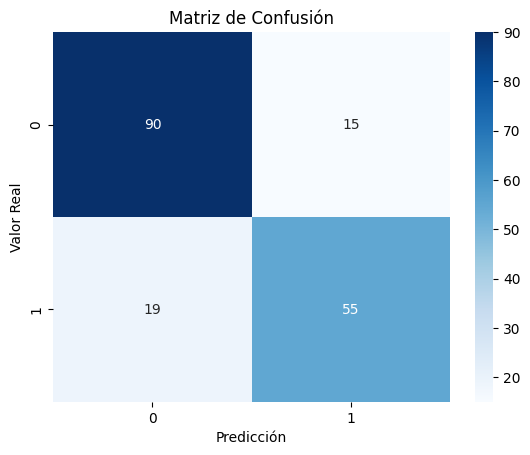

In [ ]:
# Visualización de la matriz de confusión
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicción')
plt.ylabel('Valor Real')
plt.title('Matriz de Confusión')
plt.show()

In [ ]:
# Mostrar coeficientes del modelo
coeficientes = pd.DataFrame({
    'Variable': X.columns,
    'Coeficiente': model.coef_[0]
})
coeficientes.sort_values(by='Coeficiente', ascending=False)

,Variable,Coeficiente
4,Fare,0.002577
1,Age,-0.030619
3,Parch,-0.108317
6,Embarked_Q,-0.112920
2,SibSp,-0.295650
7,Embarked_S,-0.399413
0,Pclass,-0.938457
5,Sex_male,-2.592309


###
 Ejemplo típico de interpretación de coeficientes

| Variable       | Coeficiente (ejemplo) | Interpretación                                                                 |
|----------------|------------------------|--------------------------------------------------------------------------------|
| `Sex_male`     | -2.6                   | Ser hombre **disminuye** la probabilidad de sobrevivir                        |
| `Pclass`       | -0.7                   | Tener un ticket de clase más baja **disminuye** la probabilidad               |
| `Fare`         | +0.01                  | Pagar más por el pasaje **aumenta** levemente la probabilidad                 |
| `Age`          | -0.03                  | Mayor edad **reduce ligeramente** la probabilidad de sobrevivir               |
| `SibSp`        | -0.4                   | Ir con más hermanos/pareja **reduce** la probabilidad (en exceso puede ser negativo) |
| `Parch`        | +0.3                   | Ir con hijos o padres **puede aumentar** la probabilidad de sobrevivir        |
